#Visualizing ISRO Knowledge Graph

###Entity and Relationship Extraction

###TYPE 1 — CIRCULAR STRATEGIC WHEEL

This creates a multi-layer circular knowledge map:

Center → ISRO

Layer 1 → Satellites

Layer 2 → Vehicles / Orbits / Applications

In [20]:
#Install Libraries
!pip install matplotlib networkx

In [21]:
#Load Data
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

triples_df = pd.read_csv("triples.csv")

/tmp/ipython-input-2458495297.py:27: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.savefig("TYPE 1: ISRO Knowledge Graph.jpeg", dpi=300, bbox_inches='tight')
/tmp/ipython-input-2458495297.py:27: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.savefig("TYPE 1: ISRO Knowledge Graph.jpeg", dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


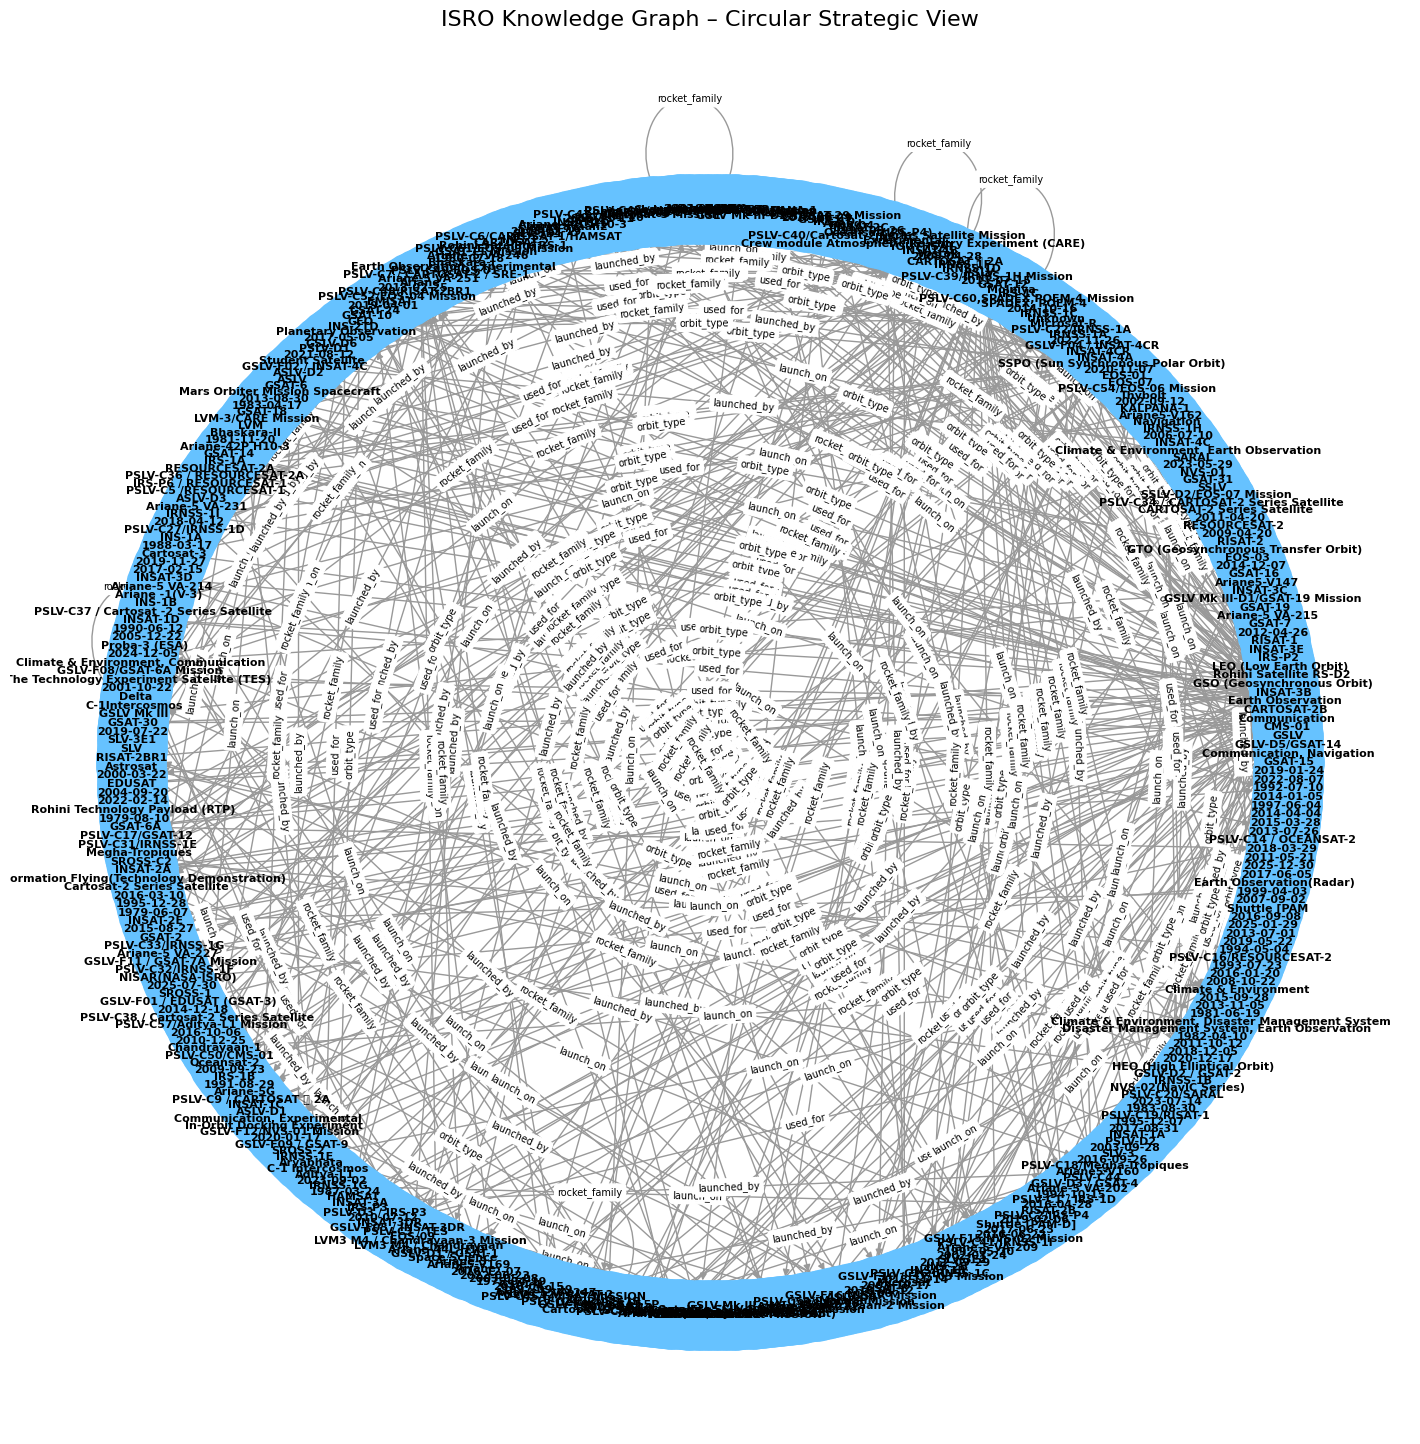

In [3]:
#Create Circular Layout
G = nx.DiGraph()

for _, row in triples_df.iterrows():
    G.add_edge(row["Entity1"], row["Entity2"], label=row["Relation"])

plt.figure(figsize=(14,14))
pos = nx.circular_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color="#66c2ff",
    font_size=8,
    font_weight="bold",
    edge_color="#999999"
)

edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

plt.title("ISRO Knowledge Graph – Circular Strategic View", fontsize=16)

#CASE 1 — Save NetworkX Graph as PNG (Most Common)
plt.savefig("TYPE 1: ISRO Knowledge Graph.jpeg", dpi=300, bbox_inches='tight')
plt.show()


###TYPE 2 — VISUAL STORYTELLING INFOGRAPHIC

In [4]:
#Aggregate Data
sat_count = triples_df[triples_df["Relation"]=="launched_by"]["Entity1"].nunique()
vehicle_count = triples_df[triples_df["Relation"]=="launched_by"]["Entity2"].nunique()
orbit_count = triples_df[triples_df["Relation"]=="orbit_type"]["Entity2"].nunique()
application_count = triples_df[triples_df["Relation"]=="used_for"]["Entity2"].nunique()

/tmp/ipython-input-3874404819.py:12: UserWarning: Glyph 128752 (\N{SATELLITE}) missing from font(s) DejaVu Sans.
  plt.savefig("TYPE 2: ISRO Knowledge Graph.jpeg", dpi=300, bbox_inches='tight')
/tmp/ipython-input-3874404819.py:12: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.savefig("TYPE 2: ISRO Knowledge Graph.jpeg", dpi=300, bbox_inches='tight')
/tmp/ipython-input-3874404819.py:12: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.savefig("TYPE 2: ISRO Knowledge Graph.jpeg", dpi=300, bbox_inches='tight')
/tmp/ipython-input-3874404819.py:12: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  plt.savefig("TYPE 2: ISRO Knowledge Graph.jpeg", dpi=300, bbox_inches='tight')
/tmp/ipython-input-3874404819.py:12: UserWarning: Glyph 128752 (\N{SATELLITE}) missing from font(s) DejaVu Sans.
  plt.savefig("TYPE 2: ISRO Knowledge Graph.jpeg", dpi=300, bbox_inches='tight')
/tmp/ipyt

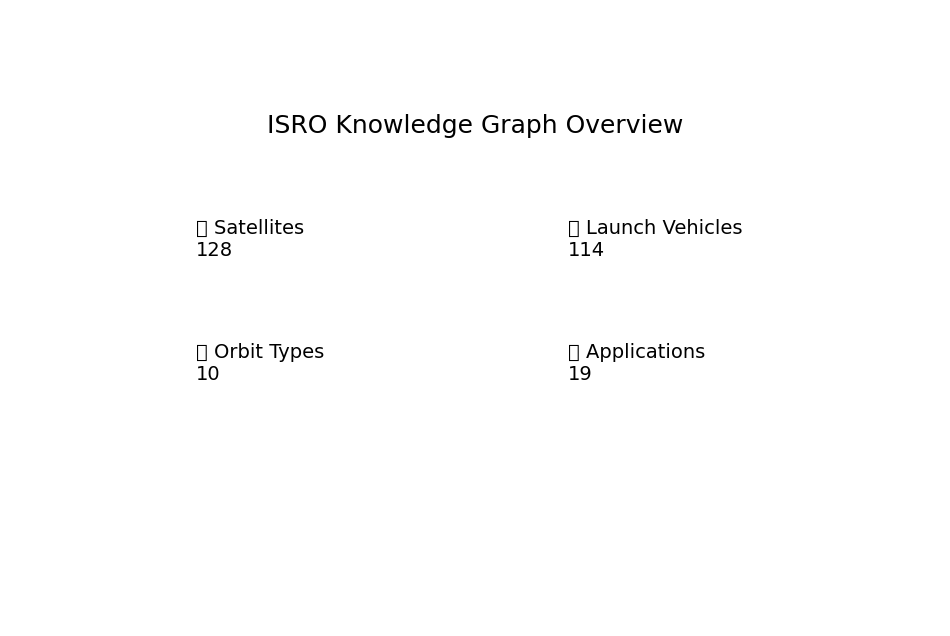

In [5]:
#Create Infographic Layout
plt.figure(figsize=(12,8))

plt.text(0.5, 0.8, "ISRO Knowledge Graph Overview", fontsize=18, ha='center')

plt.text(0.2, 0.6, f"🛰 Satellites\n{sat_count}", fontsize=14)
plt.text(0.6, 0.6, f"🚀 Launch Vehicles\n{vehicle_count}", fontsize=14)
plt.text(0.2, 0.4, f"🌍 Orbit Types\n{orbit_count}", fontsize=14)
plt.text(0.6, 0.4, f"📡 Applications\n{application_count}", fontsize=14)

plt.axis('off')
plt.savefig("TYPE 2: ISRO Knowledge Graph.jpeg", dpi=300, bbox_inches='tight')
plt.show()

###TYPE 3 — COLOR-CODED ANALYTICAL CHARTS

In [6]:
#Distribution by Application
app_counts = triples_df[triples_df["Relation"]=="used_for"]["Entity2"].value_counts()

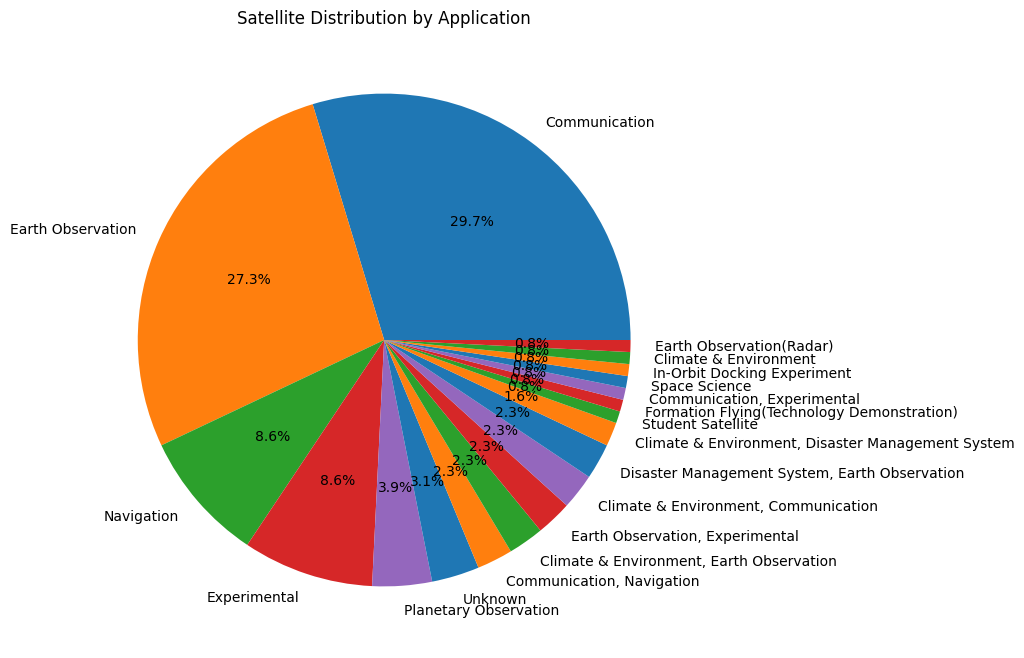

In [7]:
#Pie Chart (Color-Coded)
plt.figure(figsize=(8,8))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

plt.pie(
    app_counts,
    labels=app_counts.index,
    autopct='%1.1f%%',
    colors=colors
)

plt.title("Satellite Distribution by Application")
plt.savefig("TYPE 3: ISRO Knowledge Graph (by application).jpeg", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipython-input-3758906664.py:10: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.savefig("TYPE 3: ISRO Knowledge Graph (by launch).jpeg", dpi=300, bbox_inches='tight')
/tmp/ipython-input-3758906664.py:10: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.savefig("TYPE 3: ISRO Knowledge Graph (by launch).jpeg", dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


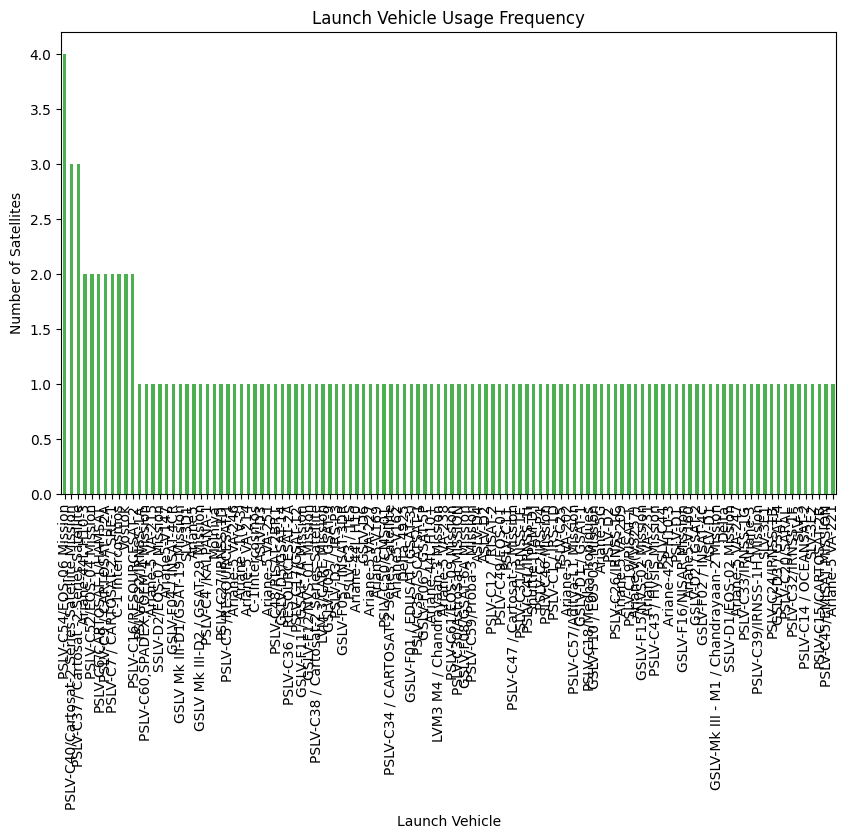

In [8]:
#Bar Chart – Launch Vehicles
vehicle_counts = triples_df[triples_df["Relation"]=="launched_by"]["Entity2"].value_counts()

plt.figure(figsize=(10,6))
vehicle_counts.plot(kind='bar', color="#4CAF50")
plt.title("Launch Vehicle Usage Frequency")
plt.xlabel("Launch Vehicle")
plt.ylabel("Number of Satellites")
plt.xticks(rotation=90)
plt.savefig("TYPE 3: ISRO Knowledge Graph (by launch).jpeg", dpi=300, bbox_inches='tight')
plt.show()

###TYPE 4 - PREMIUM INTERACTIVE DASHBOARD (VERY ATTRACTIVE)

In [9]:
!pip install plotly
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.9 MB/s eta 0:00:00


In [10]:
import plotly.express as px

fig = px.bar(
    vehicle_counts,
    title="Launch Vehicle Usage",
    labels={'value':'Count', 'index':'Vehicle'}
)

fig.show()

#CASE 2 — Save Plotly 2D Graph as PNG
#fig.write_image("TYPE 4: ISRO Knowledge Graph.png", width=1200, height=800)


/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




###TYPE 5: — 3D Knowledge Graph

In [11]:
#cOLOUR tHEME
ISRO_BLUE = "#003366"
ISRO_LIGHT_BLUE = "#1f77b4"
ISRO_ACCENT = "#00AEEF"
ISRO_WHITE = "#FFFFFF"

In [12]:
!pip install plotly

In [13]:
import plotly.graph_objects as go
import networkx as nx
import numpy as np

G = nx.from_pandas_edgelist(triples_df, "Entity1", "Entity2", create_using=nx.DiGraph())

pos = nx.spring_layout(G, dim=3, seed=42)

x_nodes = [pos[node][0] for node in G.nodes()]
y_nodes = [pos[node][1] for node in G.nodes()]
z_nodes = [pos[node][2] for node in G.nodes()]

node_trace = go.Scatter3d(
    x=x_nodes,
    y=y_nodes,
    z=z_nodes,
    mode='markers+text',
    text=list(G.nodes()),
    marker=dict(
        size=8,
        color="#00AEEF"
    )
)

edge_trace = []
for edge in G.edges():
    x0, y0, z0 = pos[edge[0]]
    x1, y1, z1 = pos[edge[1]]

    edge_trace.append(
        go.Scatter3d(
            x=[x0, x1],
            y=[y0, y1],
            z=[z0, z1],
            mode='lines',
            line=dict(color="#003366", width=2),
            hoverinfo='none'
        )
    )

fig = go.Figure(data=[node_trace] + edge_trace)
fig.update_layout(
    title="ISRO 3D Knowledge Graph",
    showlegend=False,
    paper_bgcolor="#FFFFFF"
)

fig.show()
#fig.write_image("TYPE 5: ISRO Knowledge Graph.png", width=1200, height=800)

###TYPE 6: MIND MAP–STYLE GRAPH

In [14]:
#Install Required Lib
!pip install networkx matplotlib

In [15]:
# LOAD TRIPLES DATA
import pandas as pd

triples_df = pd.read_csv("/content/triples.csv")
triples_df.head()


,Entity1,Relation,Entity2
0,GSAT-15,used_for,"Communication, Navigation"
1,GSLV-D5/GSAT-14,rocket_family,GSLV
2,CMS-01,used_for,Communication
3,CARTOSAT-2B,used_for,Earth Observation
4,INSAT-3B,orbit_type,GSO (Geosynchronous Orbit)


In [16]:
#BUILD GRAPH STRUCTURE
import networkx as nx

G = nx.DiGraph()

for _, row in triples_df.iterrows():
    G.add_edge(row["Entity1"], row["Entity2"], label=row["Relation"])


/tmp/ipython-input-921892118.py:22: UserWarning:

Glyph 150 (\x96) missing from font(s) DejaVu Sans.

/tmp/ipython-input-921892118.py:22: UserWarning:

Glyph 150 (\x96) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 150 (\x96) missing from font(s) DejaVu Sans.



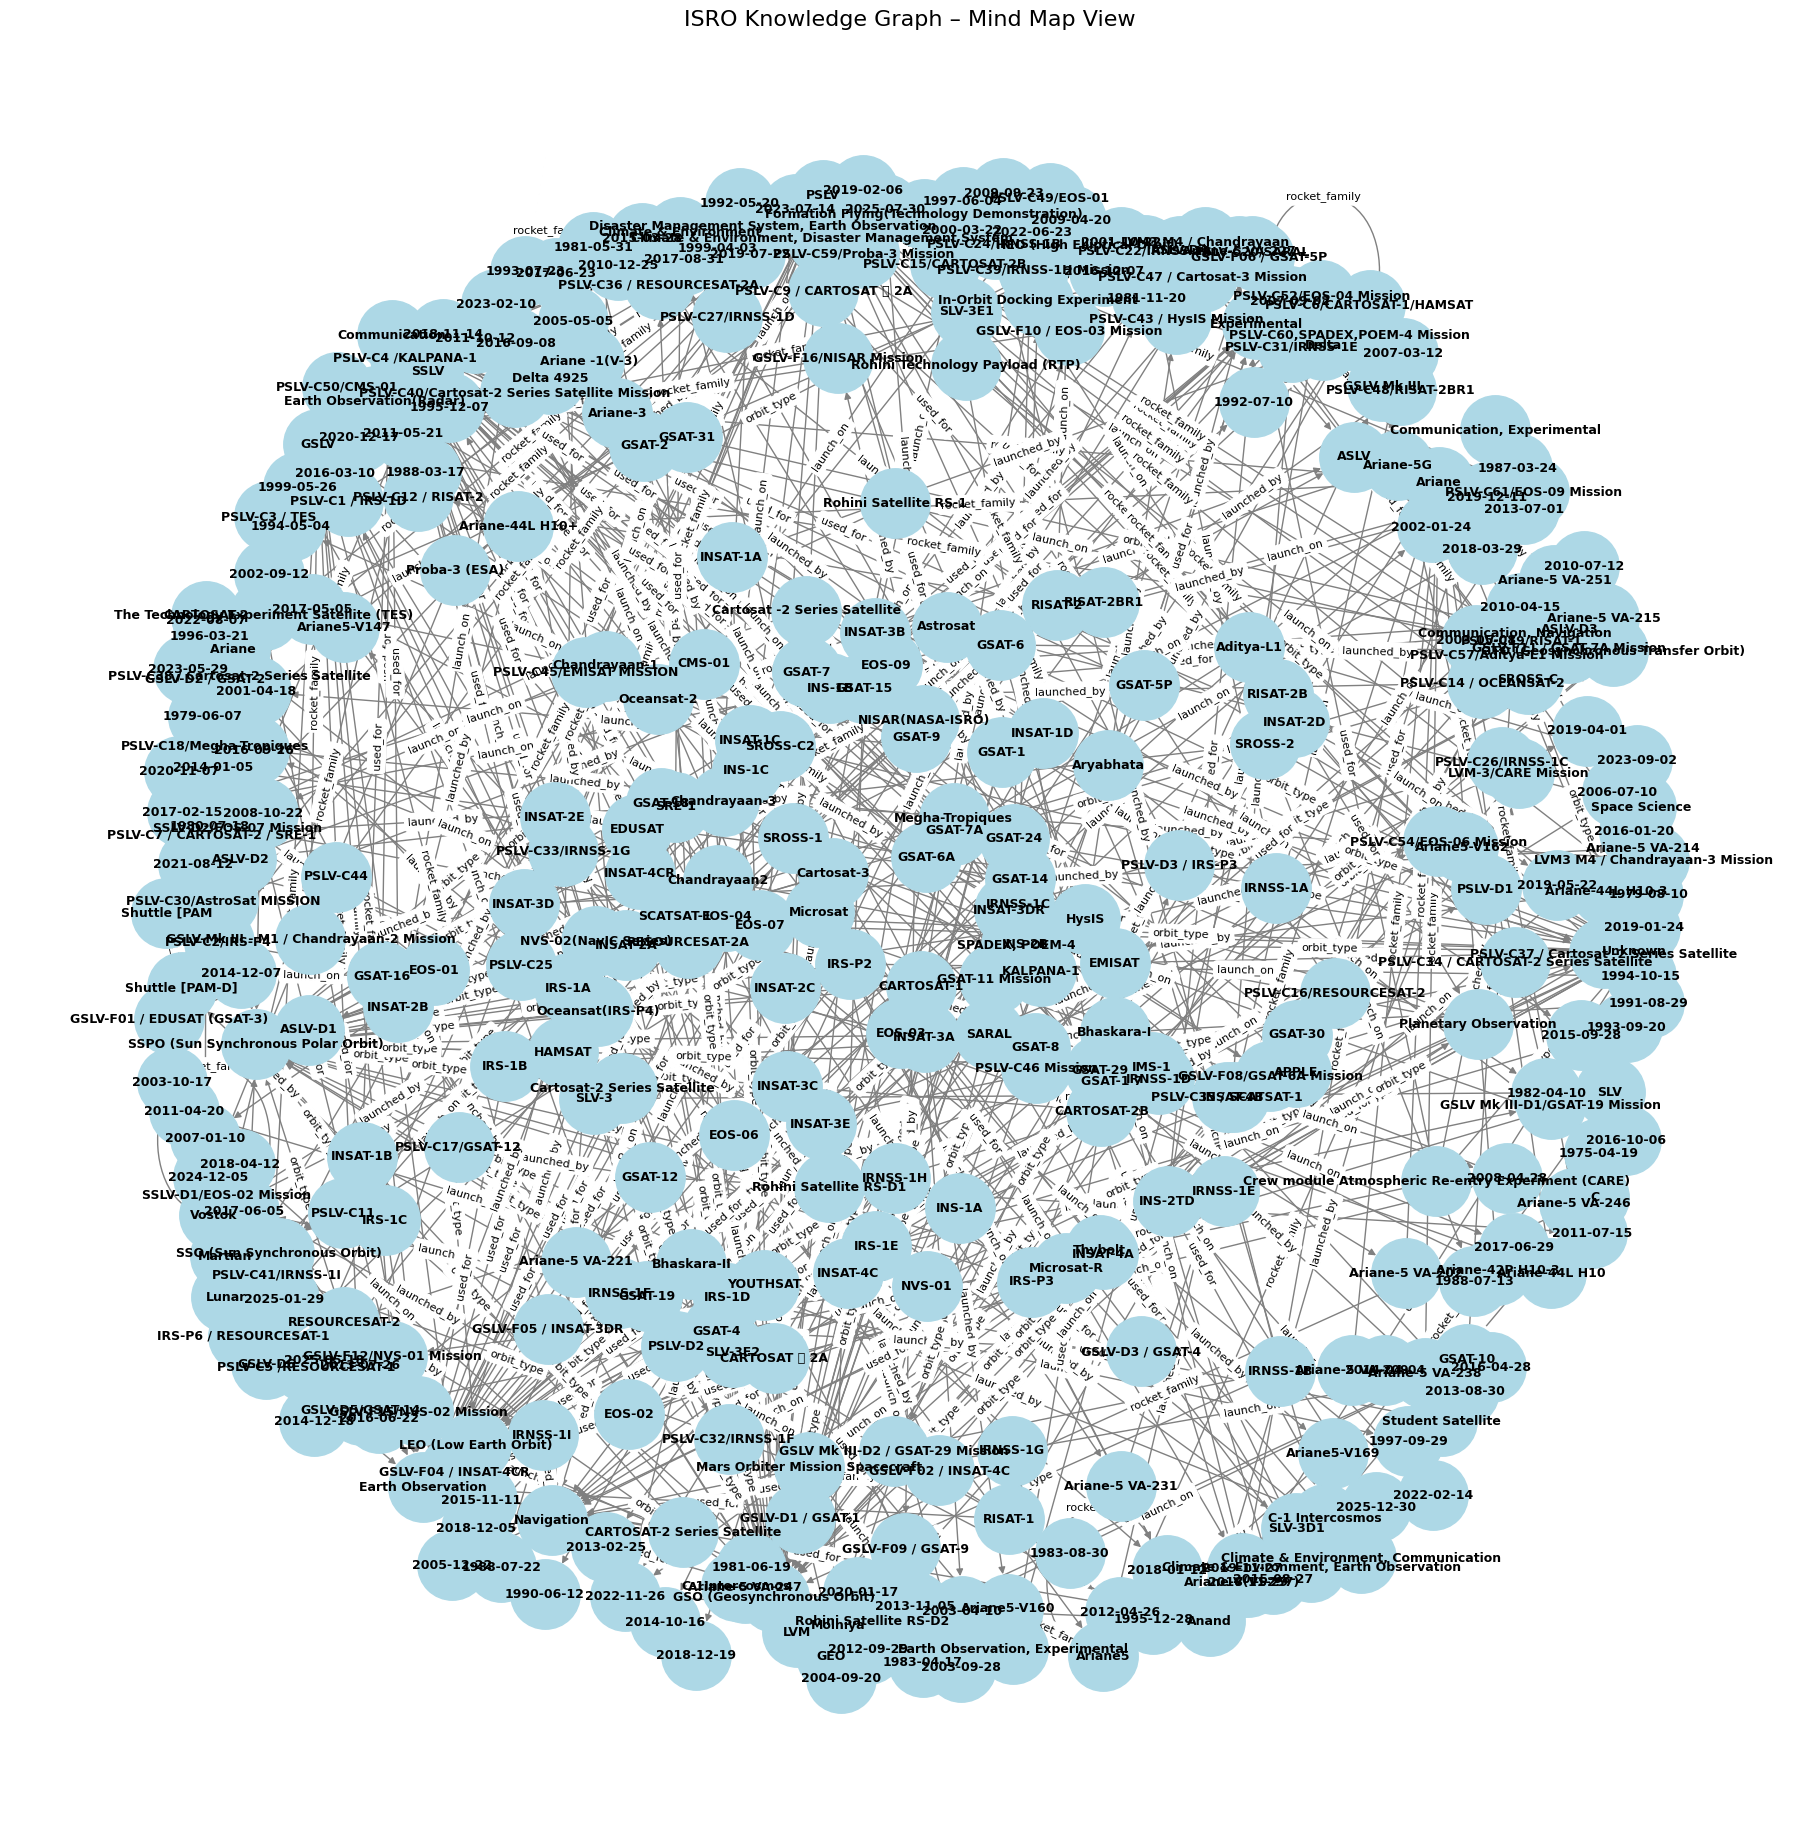

In [17]:
#CREATE MIND MAP LAYOUT (SPRING LAYOUT)
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 18))
pos = nx.spring_layout(G, k=0.6, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color="lightblue",
    font_size=9,
    font_weight="bold",
    edge_color="gray"
)

edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("ISRO Knowledge Graph – Mind Map View", fontsize=16)
plt.savefig("TYPE 6: ISRO Knowledge Graph.jpeg", dpi=300, bbox_inches='tight')
plt.show()


###TYPE 7: SATELLITE-CENTRIC MIND MAP

In [18]:
#FILTER FOR ONE SATELLITE
satellite_name = "Chandrayaan-3"

filtered = triples_df[
    (triples_df["Entity1"] == satellite_name) |
    (triples_df["Entity2"] == satellite_name)
]
filtered


,Entity1,Relation,Entity2
68,Chandrayaan-3,orbit_type,Lunar
326,Chandrayaan-3,launched_by,LVM3 M4 / Chandrayaan-3 Mission
461,Chandrayaan-3,used_for,Planetary Observation
475,Chandrayaan-3,launch_on,2023-07-14


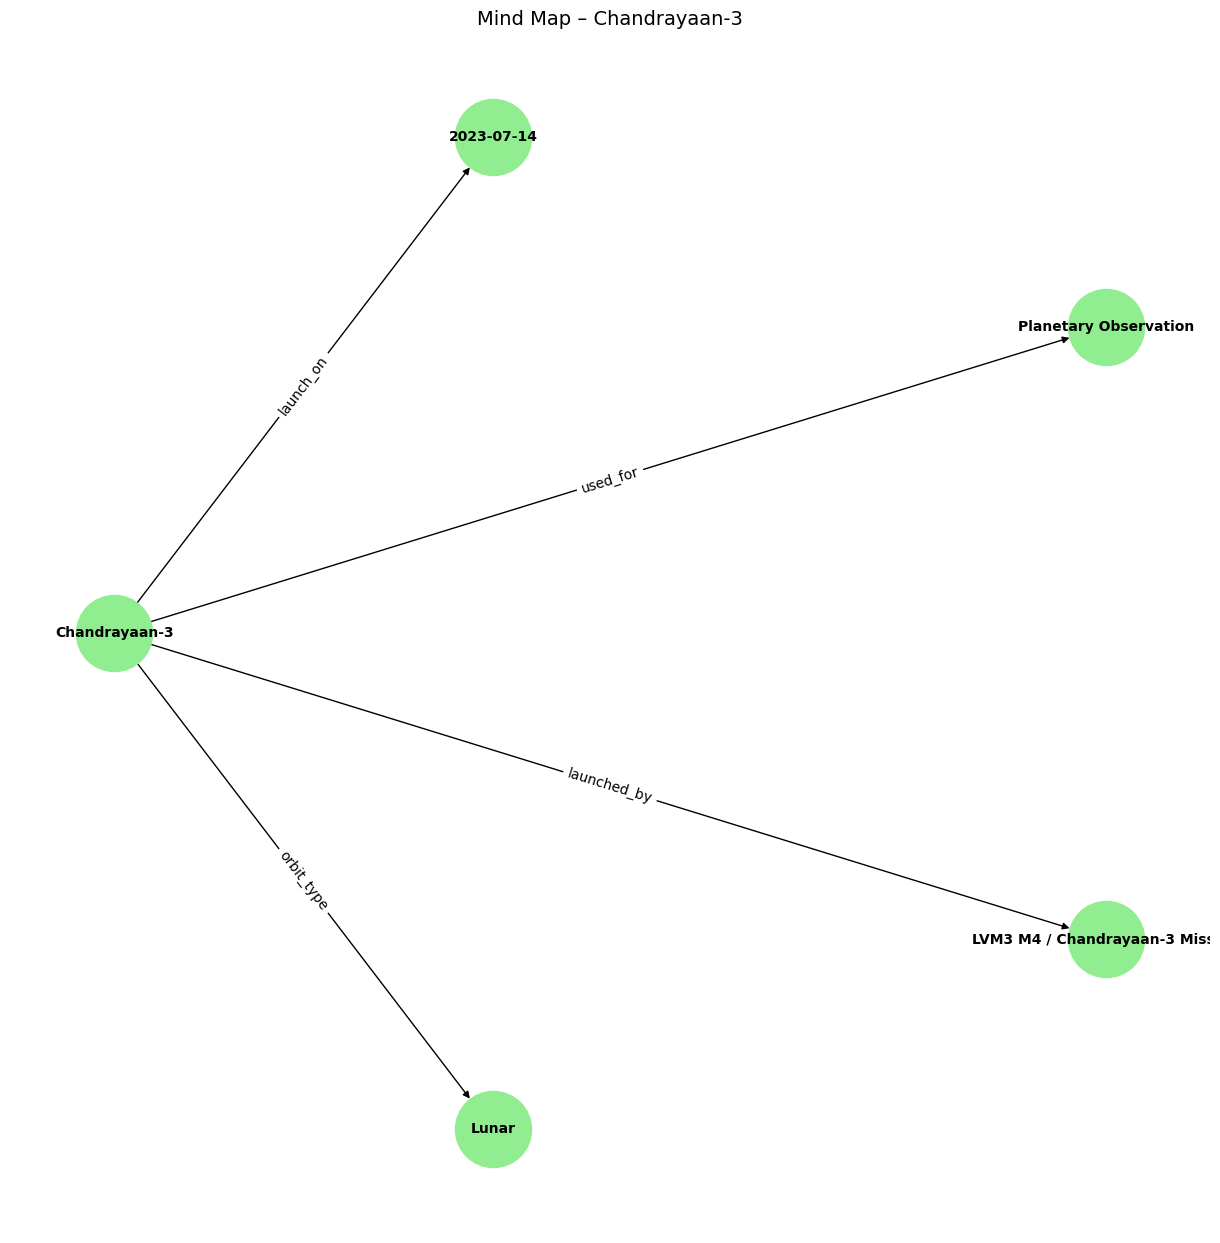

In [19]:
#DRAW CLEAN MIND MAP
G2 = nx.DiGraph()

for _, row in filtered.iterrows():
    G2.add_edge(row["Entity1"], row["Entity2"], label=row["Relation"])

plt.figure(figsize=(12, 12))
pos = nx.shell_layout(G2)

nx.draw(
    G2,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightgreen",
    font_size=10,
    font_weight="bold"
)

edge_labels = nx.get_edge_attributes(G2, "label")
nx.draw_networkx_edge_labels(G2, pos, edge_labels=edge_labels)

plt.title(f"Mind Map – {satellite_name}", fontsize=14)
plt.savefig("TYPE 7: ISRO Knowledge Graph (chandrayaan-3).jpeg", dpi=300, bbox_inches='tight')
plt.show()
